# Comparing Lidar and Temperature for Thermal Landscapes Project
### Nkuhlu
 PB 11/17/22
 
Reads in rectified multiband thermal images from each site and selects images that overlap with shapefiles of inside/outside the exclosures. Compares temperature values to CHM data. 

##### Weird Things about Nkuhlu
- The shapefile has 3 columns for treatments: 
    - "Exclosure" which is either "Full"/"Partial"/"Open"
    - "TopoPositi" which is either "Upland"/"Lowland"
    - "Treatment" which is either "Inside"/"Outside"
***Note: Only including the Full and the Open Exclosure.***

In [1]:
import rasterio as rio
import numpy as np
import geopandas as gpd
from pathlib import Path
import xarray as xr
import rioxarray as rioxr
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import pandas as pd
import warnings
import seaborn as sns

# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 11})

# # # Define inputs

img_dir = Path('/n/davies_lab/Lab/data/products/2020_01-02/NkuluEP/raster/rectifiedimages/thermal')
shp_f = Path('./data/in/Polygons_AD_current/Nkuhlu_polygon.shp')

# Set site/project string for output figures and stats
projstr = 'Nkuhlu'

# Set threshold of overlap tolerance btwn images
threshold = 0.25

# # # END USER INPUTS

# Load shapefile
shp = gpd.read_file(shp_f)

# Reproject Shapefile to 32736 (if it's not already)
shp = shp.to_crs('EPSG:32736')

# FILTER SHAPEFILE for only Full and Open - 8/9/22
shp = shp.loc[((shp.Exclosure == 'Full') | (shp.Exclosure == 'Open'))]

# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 11})

# Set hue order for plotting
exclosure_hues=["Outside", "Inside"]
topo_hues = ["Upland", "Lowland"]

# NOTE: The below is discontinued as of 6/22/2022 -
# instead the code goes through all images that overlap multiple treatments
# And removes images based on the above overlap threshold
# Set number of images to consider for final image list 
# nimgs = 1000

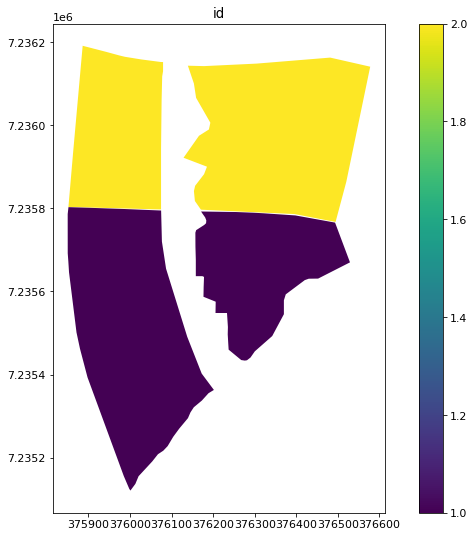

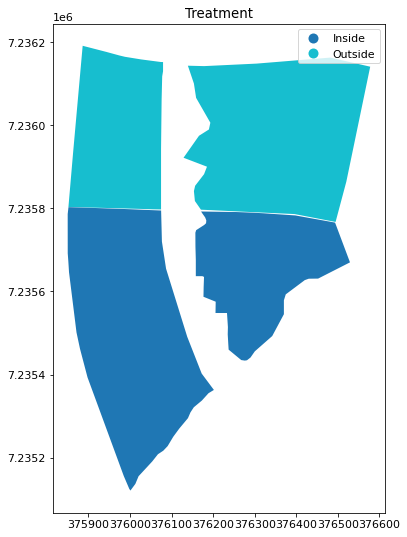

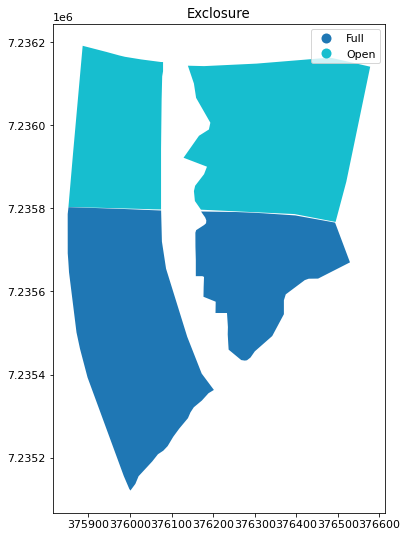

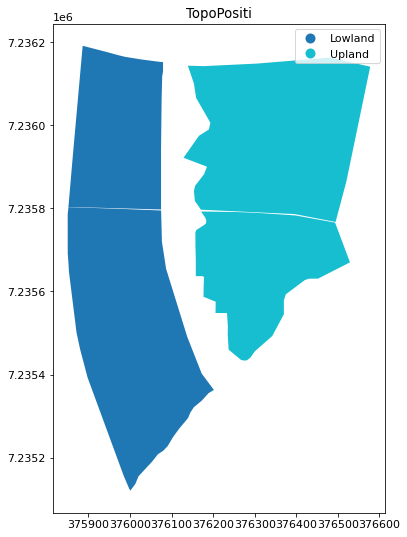

In [2]:
# Plot shapefile attributes
for c in shp.columns[0:-1]:
    shp.plot(column=c, legend=True)
    plt.title(c)
    plt.savefig(f'./figs/ShapefileFeatures_{c}_{projstr}.png', dpi=300)

### Step 1: Filter imglist to maximize overlap with polygon treatments

In [3]:
# Make list of images to loop through
img_list = [i for i in img_dir.glob('*.tif')]

# for testing,reduce the list size
# img_list = img_list[0:100]

# Initialize list of img geometries
geom_list = []

# Catching warnings
# (rio's extra samples in photo color channels error, and geoseries index warning)
# https://stackoverflow.com/questions/14463277/how-to-disable-python-warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    # warnings.filterwarnings(action='once')
    
    # Loop through each image
    for f in img_list:

        # Load image
        img = rioxr.open_rasterio(f,
                                  parse_coordinates=True,
                                  masked=True)

        # Get boundary polygon of the img for below filters
        minx, miny, maxx, maxy = img.rio.bounds()

        x_list = [minx, maxx,
                  maxx, minx,
                  minx]
        y_list = [maxy, maxy,
                  miny, miny,
                  maxy]

        # Make Boundary in to a Shapely Polygon, and save in a list
        geom_list.append(Polygon(zip(x_list, y_list)))

    # Make a Geodataframe from the result
    img_gdf = gpd.GeoDataFrame({'img':img_list, 'geometry':geom_list}, geometry='geometry', crs='EPSG:32736')

    # Use the shapefile to get the area overlap of each of the images and each of the treatments
    for ID, T, feat in zip(shp.index, shp.Treatment, shp.geometry.values):
        
        temp = img_gdf.geometry.apply(feat.intersection)

        # Save absolute area of overlap
        img_gdf[f'Area {T} {ID}'] = temp.area

        # Save percent overlap with feature
        img_gdf[f'Overlap {T} {ID}'] = temp.area / feat.area
        
        warnings.filterwarnings(action='once')

    # Use the area metric to isolate images
    # that have the largest overlap with each feature/treatment
    gdf_list = []
    
    for ID, T in zip(shp.index, shp.Treatment):
        
        # find the row of the image 
        # that covers the most area within a single feature
        maxidx = img_gdf[f'Area {T} {ID}'] == np.max(img_gdf[f'Area {T} {ID}'])
        gdf_list.append(img_gdf.loc[maxidx])
    
#     # Filter for area coverage
#     # Note: If you do this with percent coverages, as oppossed to absolute area
#     # you get images that overlap 
#     # Compute the sum overlapping area percentages
#     img_gdf['Sum'] = img_gdf.filter(like='Overlap').apply(np.nansum, axis=1)
    
#     # Filter for area coverage
#     # Note: If you do this with percent coverages, as oppossed to absolute area
#     # you get images that overlap 
#     # Compute the sum overlapping area percentages
#     img_gdf['Evenness'] = img_gdf.filter(like='Overlap').apply(lambda x: evenness(x), axis=1)

    # Sort and redindex values in ascending order of evenness, then summed percent overlap
    # img_gdf.sort_values(by=['Evenness','Sum'], axis=0, inplace=True, ascending=False, ignore_index=True
    
    

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

In [ ]:
# Try to find nearest tree for each pixel

# x = grass.x.data.flatten()
# y = grass.y.data.flatten()

# xmesh, ymesh = np.meshgrid(x,y)

# # Use the grass dataarray to subset x and ys to only grass pixels
# # (masks non grass x and y values as nan)
# xmesh_g = np.where(np.isnan(grass.data.squeeze(), where=False), xmesh, np.nan)
# ymesh_g = np.where(np.isnan(grass.data.squeeze(), where=False), ymesh, np.nan)

# # same thing with tree pixels
# xmesh_t = np.where(np.isnan(tree.data.squeeze(), where=False), xmesh, np.nan)
# ymesh_t = np.where(np.isnan(tree.data.squeeze(), where=False), ymesh, np.nan)

# dtotree = []
# for xi, yi in zip(xmesh_g.flatten(), ymesh_g.flatten()):
    
#     if not np.isnan(xi):

#         distgrid = np.sqrt((xmesh_t - xi)**2 + (ymesh_t - yi)**2)
#         dtotree.append(np.min(distgrid.data))
        
# NOTE: This works, but it's v slow (because you have to loop through all the coordinates
# give it a try with a rolling window instead
# https://docs.xarray.dev/en/stable/user-guide/computation.html?highlight=moving%20window#rolling-window-operations
# r = pixels.rolling(x=5, y=5)
# r.max().plot()
# plt.axis('equal')

# could also try a rasterio window, since it's difficult to iterate through the above:
# https://corteva.github.io/rioxarray/html/rioxarray.html#rioxarray.rioxarray.XRasterBase.isel_window

In [ ]:
# xmesh_g = np.where(np.isnan(grass.data.squeeze(), where=False), xmesh, np.nan)
# ymesh_g = np.where(np.isnan(grass.data.squeeze(), where=False), ymesh, np.nan)
# plt.scatter(xmesh_g.flatten(), ymesh_g.flatten(), s=0.01)

In [ ]:
# plt.imshow(distgrid)
# plt.axis('equal)

In [ ]:
# Closest tree to each pixel analysis
for xi, yi in x, y:
    
    np.sqrt((tree.x - x)**2 + (tree.y - y)**2)

In [ ]:
# x = pixels.x.data.flatten()
# y = pixels.y.data.flatten()

# xmesh, ymesh = np.meshgrid(x,y)

# plt.scatter(xmesh.flatten(), ymesh.flatten(), s=3, c=pixels.data.flatten()) 

In [ ]:
# mergedprodstr = '2020-01-16_NkuluEP'

# mpdir = Path(f'/n/davies_lab/Lab/data/products_merged/{mergedprodstr}/')

# chmf = [t for t in mpdir.glob('./CHM/*025m*.tif')][0]

# CHM = rioxr.open_rasterio(chmf,
#                           parse_coordinates=True,
#                           masked=True)

# # Use rio.reproject_match to cut out relevant area of the CHM
# # and resample onto the same grid with same spatial res (0.5 m)
# CHM_match = CHM.rio.reproject_match(pixels)


# Also assign coordinates (there are small differences in coordinate values)
# CHM_match = CHM_match.assign_coords({
#     "x": pixels.x,
#     "y": pixels.y,
# })
# fing magic! That works great.

# Now clip it to the feature as well
# CHM_match_clip = CHM_match.rio.clip(clipbox.intersection(feat), drop=True)   

# # "bare ground" pixels
# ground = pixels.where(((CHM_match > -0.03) & (CHM_match <= 0.05)))

# # grass
# grass = pixels.where(((CHM_match > 0.05) & (CHM_match <= 0.5)))

# # shrub
# shrub = pixels.where(((CHM_match > 0.5) & (CHM_match <= 3)))

# # tree (just using the top bracket to filter out noise points
# tree = pixels.where(((CHM_match > 3) & (CHM_match <= 20)))

# df = pd.DataFrame({'Temperature':pixel_dict['pixels_xr'][ID][i].data.flatten() - 273.15,
#                    'Exclosure':pixel_dict['Exclosure'][ID][i],
#                    'Topo':pixel_dict['Topo'][ID][i],
#                    'imgf':img})

In [ ]:
# fig, (ax1, ax2) = plt.subplots(1,2)
# ground.plot(ax=ax1)
# grass.plot(ax=ax1)
# CHM_match.plot(ax=ax2)
# ax1.axis('equal')
# ax2.axis('equal')
# fig.tight_layout()